In [ ]:
# INSTALASI LIBRARY
!pip install nltk scikit-learn pandas numpy matplotlib ipywidgets gradio -q

# OPSIONAL: aktifkan baris di bawah kalau ingin memakai SBERT (semantic search)
# !pip install sentence-transformers -q

In [ ]:
# Import library NLTK (Natural Language Toolkit)
import time               # mengukur waktu proses (indexing, respons)

# Digunakan untuk pemrosesan teks (NLP), seperti tokenisasi, stopwords, dan lemmatization
import nltk

# Modul untuk tokenisasi teks berbasis regex (opsional untuk preprocessing tambahan)
import re

# Untuk operasi acak (misalnya memilih respon chatbot secara random)
import random

# Untuk menangani karakter dan simbol (punctuation)
import string

# Untuk menampilkan peringatan (warnings) dan mengontrolnya
import warnings

# Library untuk manipulasi data tabel
import pandas as pd

# Library untuk komputasi numerik
import numpy as np

# Menonaktifkan warning agar output lebih bersih
warnings.filterwarnings('ignore')

# Tokenisasi: memecah teks menjadi kata-kata
from nltk.tokenize import word_tokenize

# Stopwords: kumpulan kata umum yang biasanya tidak membawa makna penting
# Contoh: "dan", "yang", "di", "the", dll
from nltk.corpus import stopwords

# Lemmatizer: mengubah kata ke bentuk dasarnya (contoh: "running" -> "run")
from nltk.stem import WordNetLemmatizer

# TF-IDF: mengubah teks menjadi representasi numerik berbobot
# Kata yang sering muncul di dokumen tapi jarang di dokumen lain akan diberi bobot tinggi
from sklearn.feature_extraction.text import TfidfVectorizer

# Cosine similarity: mengukur tingkat kemiripan antar dua vektor teks
# Nilai mendekati 1 berarti sangat mirip
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:


warnings.filterwarnings('ignore')

# TF-IDF: mengubah teks menjadi representasi numerik berbobot
from sklearn.feature_extraction.text import TfidfVectorizer

# Cosine similarity: mengukur kemiripan antar dua vektor teks (1 = identik)
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# SETUP NLTK (dengan fallback)
# ============================================================
NLTK_OK = False
try:
    import nltk
    for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
        nltk.download(pkg, quiet=True)

    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer

    word_tokenize("test sentence")          # uji coba, kalau gagal lompat ke except
    _lem = WordNetLemmatizer()
    _lem.lemmatize("running", pos='v')
    NLTK_OK = True
    print("✅ NLTK siap digunakan (punkt, stopwords, wordnet)")
except Exception as e:
    print(f"⚠️  NLTK tidak tersedia ({type(e).__name__}) → memakai fallback regex tokenizer")

# ============================================================
# FLAG SBERT (opsional)
# ============================================================
# ENABLE_SBERT = True  -> pakai embedding semantik (lebih pintar, lebih lambat)
# ENABLE_SBERT = False -> pakai TF-IDF saja (cepat, sudah cukup akurat)
ENABLE_SBERT = False

USE_SBERT = False
SBERT_MODEL = None
if ENABLE_SBERT:
    try:
        from sentence_transformers import SentenceTransformer, util
        SBERT_MODEL = SentenceTransformer('all-MiniLM-L6-v2')
        USE_SBERT = True
        print("✅ SBERT aktif: all-MiniLM-L6-v2")
    except Exception as e:
        print(f"⚠️  SBERT gagal dimuat ({type(e).__name__}) → otomatis fallback ke TF-IDF")

print(f"\nMode retrieval : {'SBERT (semantic)' if USE_SBERT else 'TF-IDF (lexical)'}")

✅ NLTK siap digunakan (punkt, stopwords, wordnet)

Mode retrieval : TF-IDF (lexical)


In [ ]:
# ============================================================
# 3.1 — LOAD DATASET
# ============================================================
# Ganti path ini kalau file diletakkan di lokasi lain.
# Di Google Colab, upload dulu medquad.csv lewat panel Files di kiri,
# atau mount Google Drive:
#from google.colab import drive; drive.mount('/content/drive')
CSV_PATH = '/content/sample_data/medquad.csv'

df_raw = pd.read_csv(CSV_PATH)

print("📂 Dataset mentah berhasil dimuat")
print(f"   Jumlah baris   : {len(df_raw):,}")
print(f"   Jumlah kolom   : {df_raw.shape[1]}")
print(f"   Nama kolom     : {list(df_raw.columns)}")
print("\n🔎 Missing value per kolom:")
print(df_raw.isna().sum().to_string())
print("\n📊 Distribusi sumber (institusi):")
print(df_raw['source'].value_counts().to_string())

df_raw.head(3)

📂 Dataset mentah berhasil dimuat
   Jumlah baris   : 16,412
   Jumlah kolom   : 4
   Nama kolom     : ['question', 'answer', 'source', 'focus_area']

🔎 Missing value per kolom:
question       0
answer         5
source         0
focus_area    14

📊 Distribusi sumber (institusi):
source
GHR                  5430
GARD                 5394
NIDDK                1192
NINDS                1088
MPlusHealthTopics     981
NIHSeniorHealth       769
CancerGov             729
NHLBI                 559
CDC                   270


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma


In [ ]:
# ============================================================
# 3.2 — DATA CLEANING
# ============================================================
df = df_raw.copy()
n0 = len(df)

# (1) Buang baris yang kolom pentingnya kosong
df = df.dropna(subset=['question', 'answer', 'focus_area'])

# (2) Rapikan spasi di awal/akhir teks
for col in ['question', 'answer', 'focus_area', 'source']:
    df[col] = df[col].astype(str).str.strip()

# (3) Buang jawaban yang terlalu pendek (biasanya artefak scraping, tidak informatif)
df = df[df['answer'].str.len() >= 50]

# (4) Buang duplikat pertanyaan — pertahankan jawaban TERPANJANG (paling lengkap)
df['answer_len'] = df['answer'].str.len()
df = (df.sort_values('answer_len', ascending=False)
        .drop_duplicates(subset=['question'], keep='first'))

# (5) Reset index supaya posisi baris = posisi vektor di matriks TF-IDF
df = df.sort_index().reset_index(drop=True)

print("🧹 CLEANING SELESAI")
print(f"   Sebelum : {n0:,} baris")
print(f"   Sesudah : {len(df):,} baris  (terbuang {n0 - len(df):,} baris)")
print(f"   Topik (focus_area) unik : {df['focus_area'].nunique():,}")
print(f"   Rata-rata panjang jawaban: {df['answer_len'].mean():.0f} karakter")

🧹 CLEANING SELESAI
   Sebelum : 16,412 baris
   Sesudah : 14,941 baris  (terbuang 1,471 baris)
   Topik (focus_area) unik : 5,125
   Rata-rata panjang jawaban: 1331 karakter


In [ ]:
# ============================================================
# 3.3 — EKSTRAKSI INTENT (rule-based regex)
# ============================================================
# MedQuAD tidak punya kolom "intent", tapi pola pertanyaannya sangat konsisten.
# Kita manfaatkan itu untuk membuat label intent secara otomatis.
# Urutan aturan PENTING: yang lebih spesifik diletakkan lebih dulu,
# karena "What are the symptoms of X" juga mengandung "what are".

INTENT_RULES = [
    ('gejala',      r'symptom|signs of|sign of|what to do for'),
    ('penyebab',    r'what causes|causes of|cause of'),
    ('pengobatan',  r'treatment|how to treat|therapy|therapies|medicat'),
    ('pencegahan',  r'prevent'),
    ('diagnosis',   r'diagnos|how to diagnose|test for|screening'),
    ('prevalensi',  r'how many people|how common|frequency'),
    ('genetik',     r'genetic change|inherit|hereditary|mutation'),
    ('penelitian',  r'research|clinical trial'),
    ('prognosis',   r'outlook|prognosis|survival'),
    ('komplikasi',  r'complication'),
    ('risiko',      r'who is at risk|risk factor'),
    ('definisi',    r'what is|what are|do you have information'),
]

def detect_intent(question: str) -> str:
    """Menentukan intent dari pola kalimat pertanyaan."""
    q = question.lower()
    for intent, pattern in INTENT_RULES:
        if re.search(pattern, q):
            return intent
    return 'lainnya'

df['intent'] = df['question'].apply(detect_intent)

# Kolom 'category' dibuat agar kompatibel dengan kode chatbot versi sebelumnya
df['category'] = df['focus_area']

# search_text = teks yang akan di-index (bukan yang ditampilkan ke user)
df['search_text'] = df['focus_area'] + ' ' + df['question'] + ' ' + df['intent']

print("🏷️  DISTRIBUSI INTENT HASIL EKSTRAKSI")
print(df['intent'].value_counts().to_string())

print("\n📋 Contoh hasil ekstraksi:")
df[['focus_area', 'intent', 'question']].sample(8, random_state=7)

🏷️  DISTRIBUSI INTENT HASIL EKSTRAKSI
intent
definisi      3806
gejala        2816
genetik       2530
pengobatan    2216
prevalensi    1108
penyebab       656
diagnosis      617
penelitian     369
prognosis      350
risiko         242
pencegahan     183
komplikasi      44
lainnya          4

📋 Contoh hasil ekstraksi:


,focus_area,intent,question
6262,Early infantile epileptic encephalopathy 4,gejala,What are the symptoms of Early infantile epile...
5335,Split hand/foot malformation X-linked,gejala,What are the symptoms of Split hand/foot malfo...
4499,Hypotrichosis-lymphedema-telangiectasia syndrome,gejala,What are the symptoms of Hypotrichosis-lymphed...
1428,Retinal Disorders,definisi,What is (are) Retinal Disorders ?
8342,Myasthenia Gravis,penelitian,what research (or clinical trials) is being do...
7041,Marine Toxins,pencegahan,what else can be done to prevent these disease...
5786,Abetalipoproteinemia,gejala,What are the symptoms of Abetalipoproteinemia ?
12815,fibronectin glomerulopathy,definisi,What is (are) fibronectin glomerulopathy ?


In [ ]:
# ============================================================
# 4.1 — KAMUS STOPWORDS & JEMBATAN ISTILAH ID → EN
# ============================================================
if NLTK_OK:
    english_stopwords = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
else:
    english_stopwords = set("""a an the is are was were be been being of for to in on at by
        with from and or as it its this that these those which who whom do does did done you
        your i my we our they their he she his her not no nor can could should would may might
        must have has had there here about into over under more most other some such only own
        same than too very""".split())
    lemmatizer = None

# Stopword tambahan Bahasa Indonesia (NLTK tidak menyediakannya secara default)
indonesian_stopwords = {
    'yang','dan','di','ke','dari','ini','itu','dengan','untuk','pada','adalah','atau','juga',
    'dalam','tidak','akan','ada','saya','kamu','anda','ia','mereka','kami','kita','bisa',
    'sudah','bila','jika','maka','oleh','karena','apa','bagaimana','berapa','kapan','dimana',
    'siapa','apakah','cara','lebih','sangat','dapat','nya','pun','lagi','belum','telah',
    'namun','tapi','serta','meski','agar','supaya','hal','dong','sih','kah','mau','ingin',
    # kata tanya Bahasa Inggris — ditulis eksplisit agar tetap terbuang
    # meskipun NLTK stopwords gagal diunduh
    'what','how','why','when','where','whose','which','who',
}

# PERHATIAN: jangan pernah memasukkan istilah medis ke stopwords
MEDICAL_KEEP = {'pain','blood','heart','skin','eye','bone','lung','liver','kidney','brain',
                'cancer','risk','test','cell','gene','drug','care','diet','type','stage'}
all_stopwords = (english_stopwords | indonesian_stopwords) - MEDICAL_KEEP

# Jembatan istilah: Bahasa Indonesia -> Bahasa Inggris
ID_EN_MAP = {
    'gejala':'symptoms','tanda':'signs','penyebab':'causes','sebab':'causes',
    'pengobatan':'treatment','obat':'treatment medication','mengobati':'treatment',
    'terapi':'therapy','pencegahan':'prevention','mencegah':'prevent','cegah':'prevent',
    'diagnosa':'diagnosis','diagnosis':'diagnosis','pemeriksaan':'diagnosis test',
    'penyakit':'disease','penularan':'transmission','menular':'contagious',
    'keturunan':'inherited','genetik':'genetic','risiko':'risk','komplikasi':'complication',
    'penelitian':'research','harapan':'outlook','sembuh':'cure','kambuh':'relapse',
    'jantung':'heart','paru':'lung','ginjal':'kidney','hati':'liver','otak':'brain',
    'darah':'blood','tulang':'bone','sendi':'joint','kulit':'skin','mata':'eye',
    'telinga':'ear','lambung':'stomach','usus':'intestine','saraf':'nerve','otot':'muscle',
    'payudara':'breast','paru-paru':'lung','kandungan':'uterus','prostat':'prostate',
    'kanker':'cancer','tumor':'tumor','diabetes':'diabetes','kencing':'urinary',
    'manis':'mellitus','darah tinggi':'high blood pressure','hipertensi':'hypertension',
    'kolesterol':'cholesterol','stroke':'stroke','asma':'asthma','alergi':'allergy',
    'demam':'fever','panas':'fever','batuk':'cough','pilek':'cold','flu':'influenza',
    'nyeri':'pain','sakit':'pain','pusing':'dizziness','mual':'nausea','muntah':'vomiting',
    'lelah':'fatigue','letih':'fatigue','sesak':'shortness of breath','napas':'breath',
    'gatal':'itching','bengkak':'swelling','ruam':'rash','luka':'wound','infeksi':'infection',
    'radang':'inflammation','anemia':'anemia','osteoporosis':'osteoporosis',
    'depresi':'depression','cemas':'anxiety','stres':'stress','tidur':'sleep',
    'anak':'children','bayi':'infant','lansia':'elderly','hamil':'pregnancy',
    'berat badan':'weight','makanan':'diet food','olahraga':'exercise','rokok':'smoking',
}

def bridge_id_to_en(text: str) -> str:
    """Menambahkan padanan Inggris untuk istilah medis Indonesia yang terdeteksi."""
    low = ' ' + text.lower() + ' '
    extra = []
    for idw, enw in ID_EN_MAP.items():
        if re.search(r'\b' + re.escape(idw) + r'\b', low):
            extra.append(enw)
    return text + ' ' + ' '.join(extra) if extra else text

print(f"Total stopwords : {len(all_stopwords):,}")
print(f"Kamus ID→EN     : {len(ID_EN_MAP)} istilah")
print("\nContoh jembatan istilah:")
print("  'gejala kanker payudara' →", bridge_id_to_en('gejala kanker payudara'))

Total stopwords : 258
Kamus ID→EN     : 89 istilah

Contoh jembatan istilah:
  'gejala kanker payudara' → gejala kanker payudara symptoms breast cancer


In [ ]:
# ============================================================
# 4.2 — FUNGSI PREPROCESSING
# ============================================================
def tokenize(text: str):
    """Tokenisasi dengan NLTK; kalau tidak tersedia, pakai regex."""
    if NLTK_OK:
        return word_tokenize(text)
    return re.findall(r'[a-z]+', text)

def simple_lemma(word: str) -> str:
    """Lemmatizer sederhana (fallback saat WordNet tidak tersedia)."""
    if word.endswith('ies') and len(word) > 4:
        return word[:-3] + 'y'
    if word.endswith(('ses', 'xes', 'zes', 'ches', 'shes')):
        return word[:-2]
    if word.endswith('s') and not word.endswith('ss') and len(word) > 3:
        return word[:-1]
    return word

def preprocess_text(text: str) -> str:
    """
    Pipeline lengkap:
    jembatan ID→EN → lowercase → hapus non-huruf → tokenisasi
    → hapus stopwords & token pendek → lemmatisasi → gabung kembali
    """
    text = bridge_id_to_en(str(text))          # 0. jembatan istilah
    text = text.lower()                        # 1. normalisasi
    text = re.sub(r'[^a-z\s]', ' ', text)      # 2. hapus angka & tanda baca
    tokens = tokenize(text)                    # 3. tokenisasi
    tokens = [t for t in tokens                # 4. stopword removal
              if t not in all_stopwords and len(t) > 2]
    if NLTK_OK:                                # 5. lemmatisasi
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    else:
        tokens = [simple_lemma(t) for t in tokens]
    return ' '.join(tokens)

# ── Uji coba preprocessing ──
print("🧪 TEST PREPROCESSING")
for t in ["What are the symptoms of Glaucoma ?",
          "How to prevent Diabetes ?",
          "gejala kanker payudara",
          "cara mencegah darah tinggi"]:
    print(f"  '{t}'\n     → '{preprocess_text(t)}'")

🧪 TEST PREPROCESSING
  'What are the symptoms of Glaucoma ?'
     → 'symptom glaucoma'
  'How to prevent Diabetes ?'
     → 'prevent diabetes diabetes'
  'gejala kanker payudara'
     → 'gejala kanker payudara symptom breast cancer'
  'cara mencegah darah tinggi'
     → 'mencegah darah tinggi prevent blood high blood pressure'


In [ ]:
# ============================================================
# 4.3 — TERAPKAN KE SELURUH DATASET
# ============================================================
t0 = time.time()
df['processed_question'] = df['search_text'].apply(preprocess_text)
print(f"✅ Preprocessing {len(df):,} baris selesai dalam {time.time() - t0:.2f} detik")

df[['question', 'intent', 'processed_question']].head(5)

✅ Preprocessing 14,941 baris selesai dalam 21.48 detik


,question,intent,processed_question
0,What is (are) Glaucoma ?,definisi,glaucoma glaucoma definisi
1,What causes Glaucoma ?,penyebab,glaucoma cause glaucoma penyebab cause
2,What are the symptoms of Glaucoma ?,gejala,glaucoma symptom glaucoma gejala symptom
3,What are the treatments for Glaucoma ?,pengobatan,glaucoma treatment glaucoma pengobatan treatment
4,Who is at risk for Glaucoma? ?,risiko,glaucoma risk glaucoma risiko risk


In [ ]:
# ============================================================
# 5.1 — MEMBANGUN INDEX TF-IDF
# ============================================================
t0 = time.time()

vectorizer_demo = TfidfVectorizer(
    ngram_range=(1, 2),      # unigram + bigram
    max_features=60000,      # batas ukuran vocabulary
    sublinear_tf=True,       # 1 + log(tf)
    min_df=1,                # jangan buang istilah langka
)
tfidf_demo = vectorizer_demo.fit_transform(df['processed_question'])

print(f"⏱️  Waktu indexing : {time.time() - t0:.2f} detik")
print(f"📐 Ukuran matriks  : {tfidf_demo.shape[0]:,} dokumen × {tfidf_demo.shape[1]:,} fitur")
print(f"💾 Sparsity        : {100 * (1 - tfidf_demo.nnz / (tfidf_demo.shape[0] * tfidf_demo.shape[1])):.4f}% sel bernilai nol")

# ============================================================
# 5.2 — DEMO COSINE SIMILARITY
# ============================================================
def demo_search(query, k=3):
    qv = vectorizer_demo.transform([preprocess_text(query)])
    sims = cosine_similarity(qv, tfidf_demo).flatten()
    top = sims.argsort()[-k:][::-1]
    print(f"\n🔍 Query: '{query}'")
    for rank, i in enumerate(top, 1):
        print(f"   {rank}. [{sims[i]:.3f}] ({df.iloc[i]['intent']}) {df.iloc[i]['question'][:75]}")

demo_search("what are the symptoms of glaucoma")
demo_search("how can I prevent diabetes")
demo_search("gejala kanker payudara")

⏱️  Waktu indexing : 1.04 detik
📐 Ukuran matriks  : 14,941 dokumen × 28,336 fitur
💾 Sparsity        : 99.9621% sel bernilai nol

🔍 Query: 'what are the symptoms of glaucoma'
   1. [0.750] (gejala) What are the symptoms of Glaucoma ?
   2. [0.464] (gejala) What are the symptoms of Glaucoma 3 primary infantile B ?
   3. [0.446] (gejala) What are the symptoms of Glaucoma sleep apnea ?

🔍 Query: 'how can I prevent diabetes'
   1. [0.664] (definisi) What is (are) Diabetes ?
   2. [0.522] (pencegahan) How to prevent Diabetes ?
   3. [0.385] (gejala) What to do for Prevent diabetes problems: Keep your diabetes under control 

🔍 Query: 'gejala kanker payudara'
   1. [0.881] (gejala) What are the symptoms of Breast Cancer ?
   2. [0.630] (definisi) What is (are) Breast Cancer ?
   3. [0.630] (definisi) What is (are) breast cancer ?


In [ ]:
class MedQuADChatbotEngine:
    """
    MedQuAD Chatbot Engine

    Fitur:
    ✔ Rule-based untuk kondisi darurat, salam, dan pertanyaan kapabilitas
    ✔ Top-K retrieval (bukan cuma 1 hasil)
    ✔ Keyword re-ranking + intent boosting
    ✔ Memori percakapan (context-aware follow-up)
    ✔ Threshold filter — lebih baik jujur tidak tahu daripada salah
    ✔ Atribusi sumber (source + focus_area) di setiap jawaban
    """

    # ====================================================================
    # FUNGSI 1: CONSTRUCTOR
    # ====================================================================
    def __init__(self, dataframe, threshold=0.18, top_k=5, max_answer_chars=1200):
        """
        Parameter
        ---------
        dataframe : pd.DataFrame
            Wajib punya kolom: question, processed_question, answer,
            focus_area, intent, source
        threshold : float
            Batas minimal similarity. TF-IDF skornya rendah (0.1-0.9) → 0.18.
            Kalau memakai SBERT, otomatis dinaikkan ke 0.35.
        top_k : int
            Berapa kandidat teratas yang diambil sebelum re-ranking.
        max_answer_chars : int
            Batas panjang jawaban yang ditampilkan (MedQuAD sangat panjang).
        """
        self.df = dataframe.reset_index(drop=True)
        self.threshold = 0.35 if USE_SBERT else threshold
        self.top_k = top_k
        self.max_answer_chars = max_answer_chars
        self.conversation_history = []      # menyimpan pertanyaan-pertanyaan user
        self.last_focus = None              # topik penyakit terakhir yang dibahas

        self._build_index()
        self._define_rules()

    # ====================================================================
    # FUNGSI 2: BUILD INDEX
    # ====================================================================
    def _build_index(self):
        """Mengubah semua pertanyaan FAQ menjadi vektor, dilakukan sekali di awal."""
        t0 = time.time()

        # A. SBERT (opsional) — embedding semantik
        if USE_SBERT:
            self.sbert_embeddings = SBERT_MODEL.encode(
                self.df['search_text'].tolist(),
                convert_to_tensor=True,
                batch_size=64,
                show_progress_bar=True,
            )

        # B. TF-IDF — selalu dibangun (dipakai sebagai fallback & keyword signal)
        self.vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=60000,
            sublinear_tf=True,
            min_df=1,
        )
        self.tfidf_matrix = self.vectorizer.fit_transform(self.df['processed_question'])

        print(f"🔧 Index siap dalam {time.time() - t0:.2f} detik "
              f"| {self.tfidf_matrix.shape[0]:,} dokumen × {self.tfidf_matrix.shape[1]:,} fitur")

    # ====================================================================
    # FUNGSI 3: DEFINE RULES
    # ====================================================================
    def _define_rules(self):
        """
        Rule-based = respons berdasarkan pattern matching, tanpa perlu search.
        Dipakai untuk kasus yang HARUS 100% benar (darurat) atau yang tidak
        ada di database (salam, ucapan terima kasih).
        """
        self.rules = {
            # RULE 1 — DARURAT (prioritas tertinggi, tidak boleh salah)
            'emergency': {
                'patterns': [
                    r'(sesak.*(berat|parah|hebat)|nyeri dada.*(berat|hebat|menjalar))',
                    r'(tidak (bisa|dapat) bernapas|berhenti bernapas|henti jantung)',
                    r'\b(pingsan|kejang|tidak sadarkan diri|overdosis)\b',
                    r'(muntah darah|perdarahan hebat|bab hitam)',
                    r'(chest pain.*(severe|radiat)|can\'t breathe|cannot breathe)',
                    r'\b(unconscious|seizure|stroke symptoms now|heart attack now)\b',
                    r'(bunuh diri|mengakhiri hidup|suicide)',
                ],
                'responses': [
                    "🚨 **INI KONDISI DARURAT.**\n\n"
                    "Segera hubungi **119** (Ambulans Nasional) atau **112**, "
                    "atau langsung ke IGD rumah sakit terdekat.\n\n"
                    "Jangan menunggu jawaban chatbot untuk kondisi seperti ini. "
                    "Bila memungkinkan, minta orang di sekitar Anda untuk menemani."
                ],
            },
            # RULE 2 — SALAM
            'greeting': {
                'patterns': [r'^\s*(halo|hai|hi|hello|hey|pagi|siang|sore|malam|assalam)'],
                'responses': [
                    "👋 Halo! Saya **MedQuAD Bot**, asisten informasi kesehatan berbasis "
                    "basis data resmi NIH.\n\nSilakan tanyakan tentang suatu penyakit — "
                    "definisi, gejala, penyebab, pengobatan, atau pencegahannya.",
                    "👋 Hai! Ada yang ingin Anda ketahui seputar kesehatan hari ini?\n\n"
                    "Contoh: *\"gejala diabetes\"*, *\"how to prevent stroke\"*, "
                    "*\"pengobatan kanker payudara\"*.",
                ],
            },
            # RULE 3 — TERIMA KASIH
            'thanks': {
                'patterns': [r'\b(terima kasih|makasih|thanks|thank you|tengkyu)\b'],
                'responses': [
                    "🙏 Sama-sama! Semoga membantu. Ingat, informasi ini bersifat edukatif — "
                    "untuk keluhan yang Anda alami sendiri, tetap konsultasikan ke dokter."
                ],
            },
            # RULE 4 — KAPABILITAS
            'capability': {
                'patterns': [r'(topik apa|bisa apa|kemampuan|what can you do|help|bantuan)'],
                'responses': [None],   # diisi dinamis di _check_rules()
            },
        }

    # ====================================================================
    # FUNGSI 4: CHECK RULES
    # ====================================================================
    def _check_rules(self, text):
        """Mengembalikan respons rule-based, atau None kalau tidak ada yang cocok."""
        low = text.lower().strip()

        for intent, rule in self.rules.items():
            for pattern in rule['patterns']:
                if re.search(pattern, low):
                    if intent == 'capability':
                        top_topics = self.df['focus_area'].value_counts().head(12).index.tolist()
                        return (
                            f"💡 Saya punya **{len(self.df):,} pasangan tanya-jawab** medis "
                            f"mencakup **{self.df['focus_area'].nunique():,} topik penyakit** "
                            f"dari sumber resmi (NIH, CDC, NIDDK, NHLBI, NINDS, GARD, GHR).\n\n"
                            f"**Jenis pertanyaan yang saya pahami:** "
                            f"{', '.join(sorted(self.df['intent'].unique()))}\n\n"
                            f"**Topik terpopuler:** {', '.join(top_topics)}"
                        )
                    return random.choice(rule['responses'])
        return None

    # ====================================================================
    # FUNGSI 5: SEARCH — SBERT
    # ====================================================================
    def _search_sbert(self, query):
        q_emb = SBERT_MODEL.encode(query, convert_to_tensor=True)
        scores = util.cos_sim(q_emb, self.sbert_embeddings)[0].cpu().numpy()
        top = scores.argsort()[-self.top_k:][::-1]
        return [(int(i), float(scores[i])) for i in top]

    # ====================================================================
    # FUNGSI 6: SEARCH — TF-IDF
    # ====================================================================
    def _search_tfidf(self, query):
        q_vec = self.vectorizer.transform([preprocess_text(query)])
        scores = cosine_similarity(q_vec, self.tfidf_matrix).flatten()
        top = scores.argsort()[-self.top_k:][::-1]
        return [(int(i), float(scores[i])) for i in top]

    # ====================================================================
    # FUNGSI 7: FIND BEST MATCH (dipakai juga oleh modul evaluasi)
    # ====================================================================
    def _find_best_match(self, query):
        results = self._search_sbert(query) if USE_SBERT else self._search_tfidf(query)
        results = self._rerank(query, results)
        return results[0]          # (index, score)

    # ====================================================================
    # FUNGSI 8: RE-RANKING
    # ====================================================================
    def _rerank(self, query, results):
        """
        Menaikkan skor kandidat yang:
        (a) mengandung kata yang persis sama dengan query  → +0.03 per kata
        (b) intent-nya cocok dengan intent query           → +0.10
        Alasan: vektor kadang terlalu 'pintar' dan mengabaikan exact match.
        """
        q_intent = detect_intent(bridge_id_to_en(query))
        q_words = set(preprocess_text(query).split())

        boosted = []
        for idx, score in results:
            row = self.df.iloc[idx]
            doc_words = set(str(row['processed_question']).split())
            overlap = len(q_words & doc_words)

            bonus = 0.03 * overlap
            if row['intent'] == q_intent:
                bonus += 0.10
            boosted.append((idx, score + bonus, score))

        boosted.sort(key=lambda x: x[1], reverse=True)
        return [(i, raw) for i, _, raw in boosted]   # kembalikan skor ASLI

    # ====================================================================
    # FUNGSI 9: CONTEXT BUILDER
    # ====================================================================
    def _build_context_query(self, user_input):
        """
        Menangani pertanyaan lanjutan yang tidak menyebut subjeknya.
        Contoh: "apa itu glaukoma" lalu "bagaimana gejalanya"
        → query kedua digabung menjadi "Glaucoma bagaimana gejalanya".
        """
        words = preprocess_text(user_input).split()
        # Query pendek (< 3 kata bermakna) + ada topik sebelumnya → kemungkinan follow-up
        if len(words) < 3 and self.last_focus:
            return f"{self.last_focus} {user_input}"
        return user_input

    # ====================================================================
    # FUNGSI 10: FORMAT JAWABAN
    # ====================================================================
    def _format_answer(self, row, score):
        answer = str(row['answer']).strip()
        if len(answer) > self.max_answer_chars:
            cut = answer[:self.max_answer_chars]
            dot = cut.rfind('. ')                 # potong di akhir kalimat terdekat
            answer = (cut[:dot + 1] if dot > 200 else cut) + " …"
            answer += "\n\n*(jawaban dipotong — teks aslinya lebih panjang)*"

        method = "SBERT" if USE_SBERT else "TF-IDF"
        return (
            f"🩺 **{row['focus_area']}** — *{row['intent']}*\n\n"
            f"{answer}\n\n"
            f"---\n"
            f"📚 Sumber: **{row['source']}** (MedQuAD / NIH)  \n"
            f"🎯 Relevansi: {score:.2f} ({method})  \n"
            f"⚠️ Informasi edukatif, bukan pengganti konsultasi dokter."
        )

    # ====================================================================
    # FUNGSI 11: GET RESPONSE — FUNGSI UTAMA
    # ====================================================================
    def get_response(self, user_input):
        """
        Alur:
        1. Validasi input
        2. Cek rule-based (darurat / salam / kapabilitas)
        3. Bangun context query
        4. Retrieval Top-K
        5. Re-ranking keyword + intent
        6. Filter threshold
        7. Simpan konteks, format, kembalikan jawaban
        """
        # STEP 1 — validasi
        if not user_input or not user_input.strip():
            return "Silakan ketik pertanyaan Anda."

        # STEP 2 — rule-based (bypass pencarian)
        rule = self._check_rules(user_input)
        if rule:
            return rule

        # STEP 3 — context query
        query = self._build_context_query(user_input)

        # STEP 4 — retrieval
        results = self._search_sbert(query) if USE_SBERT else self._search_tfidf(query)

        if not results:
            return "Saya tidak menemukan informasi yang relevan."

        # STEP 5 — re-ranking
        results = self._rerank(query, results)
        best_idx, best_score = results[0]

        # STEP 6 — threshold filter
        if best_score < self.threshold:
            hint = self.df['focus_area'].value_counts().head(6).index.tolist()
            return (
                "Maaf, saya tidak menemukan jawaban yang cukup relevan di basis data saya "
                f"(skor tertinggi hanya {best_score:.2f}).\n\n"
                "Coba sebutkan **nama penyakitnya** secara spesifik, misalnya: "
                f"*{hint[0]}*, *{hint[1]}*, atau *{hint[2]}*.\n\n"
                "Basis data ini berbahasa Inggris, jadi menulis dalam Bahasa Inggris "
                "biasanya memberi hasil lebih akurat."
            )

        # STEP 7 — simpan konteks & format
        row = self.df.iloc[best_idx]
        self.conversation_history.append(user_input)
        self.last_focus = row['focus_area']

        response = self._format_answer(row, best_score)

        # Saran pertanyaan lanjutan dari topik yang sama
        related = self.df[(self.df['focus_area'] == row['focus_area']) &
                          (self.df.index != best_idx)]['question'].head(3).tolist()
        if related:
            response += "\n\n**❓ Pertanyaan terkait:**\n" + \
                        "\n".join(f"- {q}" for q in related)
        return response


# ── INISIALISASI BOT ──
bot = MedQuADChatbotEngine(df, threshold=0.18, top_k=5)
print("🤖 MedQuAD Bot siap digunakan!\n")

# ── UJI CEPAT ──
for q in ["halo", "what are the symptoms of glaucoma", "gejala diabetes", "saya pingsan"]:
    print("=" * 70)
    print(f"👤 USER : {q}")
    print(f"🤖 BOT  : {bot.get_response(q)[:320]}...\n")

🔧 Index siap dalam 0.59 detik | 14,941 dokumen × 28,336 fitur
🤖 MedQuAD Bot siap digunakan!

👤 USER : halo
🤖 BOT  : 👋 Hai! Ada yang ingin Anda ketahui seputar kesehatan hari ini?

Contoh: *"gejala diabetes"*, *"how to prevent stroke"*, *"pengobatan kanker payudara"*....

👤 USER : what are the symptoms of glaucoma
🤖 BOT  : 🩺 **Glaucoma** — *gejala*

Symptoms of Glaucoma  Glaucoma can develop in one or both eyes. The most common type of glaucoma, open-angle glaucoma, has no symptoms at first. It causes no pain, and vision seems normal. Without treatment, people with glaucoma will slowly lose their peripheral, or side vision. They seem to ...

👤 USER : gejala diabetes
🤖 BOT  : 🩺 **Diabetes** — *gejala*

Diabetes is often called a "silent" disease because it can cause serious complications even before you have symptoms. Symptoms can also be so mild that you dont notice them. An estimated 8 million people in the United States have type 2 diabetes and dont know it, according to 2012 estimate

In [ ]:
# ============================================================
# UI CHATBOT INTERAKTIF (ipywidgets)
# ============================================================
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import html as html_lib

chat_css = """
<style>
  @import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;500;600;700&display=swap');
  .medbot-container { font-family:'Plus Jakarta Sans',sans-serif; max-width:760px; margin:0 auto;
      border-radius:20px; overflow:hidden; box-shadow:0 20px 60px rgba(0,0,0,.15); background:#f8faff; }
  .medbot-header { background:linear-gradient(135deg,#0d3b2e 0%,#12695a 50%,#0f9b8e 100%);
      padding:20px 24px; color:#fff; display:flex; align-items:center; gap:14px; }
  .medbot-avatar { width:48px; height:48px; background:rgba(255,255,255,.2); border-radius:50%;
      display:flex; align-items:center; justify-content:center; font-size:24px;
      border:2px solid rgba(255,255,255,.4); }
  .medbot-title { font-size:18px; font-weight:700; }
  .medbot-subtitle { font-size:12px; opacity:.8; margin-top:2px; }
  .status-dot { width:8px; height:8px; background:#4ade80; border-radius:50%;
      display:inline-block; margin-right:5px; animation:pulse 2s infinite; }
  @keyframes pulse { 0%,100%{opacity:1} 50%{opacity:.5} }
  .medbot-chat { height:430px; overflow-y:auto; padding:20px; background:#f0fbf8;
      display:flex; flex-direction:column; gap:14px; }
  .row-user { display:flex; justify-content:flex-end; }
  .row-bot  { display:flex; justify-content:flex-start; align-items:flex-start; gap:10px; }
  .bubble-user { background:linear-gradient(135deg,#12695a,#0f9b8e); color:#fff; padding:12px 16px;
      border-radius:18px 18px 4px 18px; max-width:76%; font-size:14px; line-height:1.55; }
  .bubble-bot { background:#fff; color:#123; padding:12px 16px; border:1px solid #d8efe9;
      border-radius:18px 18px 18px 4px; max-width:82%; font-size:14px; line-height:1.6;
      white-space:pre-wrap; }
  .bot-icon { width:32px; height:32px; background:#0f9b8e; color:#fff; border-radius:50%;
      display:flex; align-items:center; justify-content:center; font-size:16px; flex:0 0 32px; }
  .medbot-footer { padding:10px 20px 16px; background:#fff; font-size:11px; color:#789;
      text-align:center; border-top:1px solid #e6f2ef; }
</style>
"""

chat_log = []   # menyimpan (peran, teks)

chat_out   = widgets.Output()
text_input = widgets.Text(placeholder='Ketik pertanyaan medis Anda…',
                          layout=widgets.Layout(width='100%'))
send_btn   = widgets.Button(description='Kirim', button_style='success',
                            layout=widgets.Layout(width='110px'))
clear_btn  = widgets.Button(description='Reset', button_style='warning',
                            layout=widgets.Layout(width='110px'))

SUGGESTIONS = ["What is Glaucoma ?", "symptoms of diabetes",
               "how to prevent stroke", "pengobatan kanker payudara"]
chips = [widgets.Button(description=s, layout=widgets.Layout(width='auto'))
         for s in SUGGESTIONS]


def md_to_html(text):
    """Konversi markdown sederhana (**bold**, *italic*) ke HTML."""
    t = html_lib.escape(str(text))
    t = re.sub(r'\*\*(.+?)\*\*', r'<b>\1</b>', t)
    t = re.sub(r'(?<!\*)\*([^*\n]+?)\*(?!\*)', r'<i>\1</i>', t)
    return t.replace('\n', '<br>')


def render():
    bubbles = []
    for role, text in chat_log:
        if role == 'user':
            bubbles.append(f'<div class="row-user"><div class="bubble-user">{md_to_html(text)}</div></div>')
        else:
            bubbles.append('<div class="row-bot"><div class="bot-icon">🩺</div>'
                           f'<div class="bubble-bot">{md_to_html(text)}</div></div>')
    with chat_out:
        clear_output(wait=True)
        display(HTML(chat_css + f"""
        <div class="medbot-container">
          <div class="medbot-header">
            <div class="medbot-avatar">🏥</div>
            <div>
              <div class="medbot-title">MedQuAD Bot</div>
              <div class="medbot-subtitle"><span class="status-dot"></span>
                   Online · {len(df):,} Q&amp;A · {df['focus_area'].nunique():,} topik · NIH</div>
            </div>
          </div>
          <div class="medbot-chat">{''.join(bubbles)}</div>
          <div class="medbot-footer">Informasi edukatif — bukan pengganti konsultasi dokter.
               Darurat: 119 / 112</div>
        </div>"""))


def handle(message):
    if not message.strip():
        return
    chat_log.append(('user', message))
    chat_log.append(('bot', bot.get_response(message)))
    render()


send_btn.on_click(lambda b: (handle(text_input.value), setattr(text_input, 'value', '')))
text_input.on_submit(lambda w: (handle(w.value), setattr(w, 'value', '')))


def do_clear(b):
    chat_log.clear()
    bot.conversation_history.clear()
    bot.last_focus = None
    chat_log.append(('bot', "👋 Halo! Saya MedQuAD Bot. Silakan tanyakan tentang "
                            "gejala, penyebab, pengobatan, atau pencegahan suatu penyakit."))
    render()


clear_btn.on_click(do_clear)
for chip in chips:
    chip.on_click(lambda b: handle(b.description))

do_clear(None)
display(chat_out,
        widgets.HBox(chips),
        widgets.HBox([text_input, send_btn, clear_btn],
                     layout=widgets.Layout(width='760px', margin='10px auto')))

Output()

In [ ]:
# ============================================================
# DEPLOYMENT ALTERNATIF: GRADIO (dapat di-share via link publik)
# ============================================================
import gradio as gr


def respond(message, history):
    """Handler chat dengan efek 'sedang mengetik'."""
    if history is None:
        history = []
    history = history + [(message, "⏳ MedQuAD Bot sedang mencari…")]
    yield "", history

    time.sleep(0.4)
    history[-1] = (message, bot.get_response(message))
    yield "", history


def clear_chat():
    bot.conversation_history = []      # reset memori percakapan
    bot.last_focus = None
    return []


custom_css = """
.gradio-container { font-family:'Plus Jakarta Sans',sans-serif; background:#f0fbf8; }
.chatbot { height:460px; }
"""

with gr.Blocks(css=custom_css, title="MedQuAD Bot") as demo:
    gr.HTML("""
      <div style="background:linear-gradient(135deg,#0d3b2e,#12695a,#0f9b8e);
                  padding:22px;border-radius:15px;color:#fff;">
        <h2 style="margin:0">🏥 MedQuAD Bot</h2>
        <p style="margin:6px 0 0;opacity:.85">
           Chatbot informasi kesehatan berbasis 16.000+ Q&A resmi NIH ·
           TF-IDF Retrieval · Informasi edukatif, bukan pengganti dokter
        </p>
      </div>""")

    chatbot_ui = gr.Chatbot(label="Percakapan", elem_classes="chatbot")
    msg = gr.Textbox(placeholder="Ketik pertanyaan medis Anda…", label="", lines=1)

    with gr.Row():
        send = gr.Button("Kirim", variant="primary")
        clear = gr.Button("Reset")

    gr.Examples(
        examples=["What is Glaucoma ?",
                  "What are the symptoms of Parkinson's Disease ?",
                  "how to prevent high blood pressure",
                  "gejala kanker payudara",
                  "pengobatan asma"],
        inputs=msg,
    )

    msg.submit(respond, [msg, chatbot_ui], [msg, chatbot_ui])
    send.click(respond, [msg, chatbot_ui], [msg, chatbot_ui])
    clear.click(clear_chat, outputs=chatbot_ui)

# share=True menghasilkan link publik sementara (berlaku 72 jam)
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2bbd4ba9f45896751b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


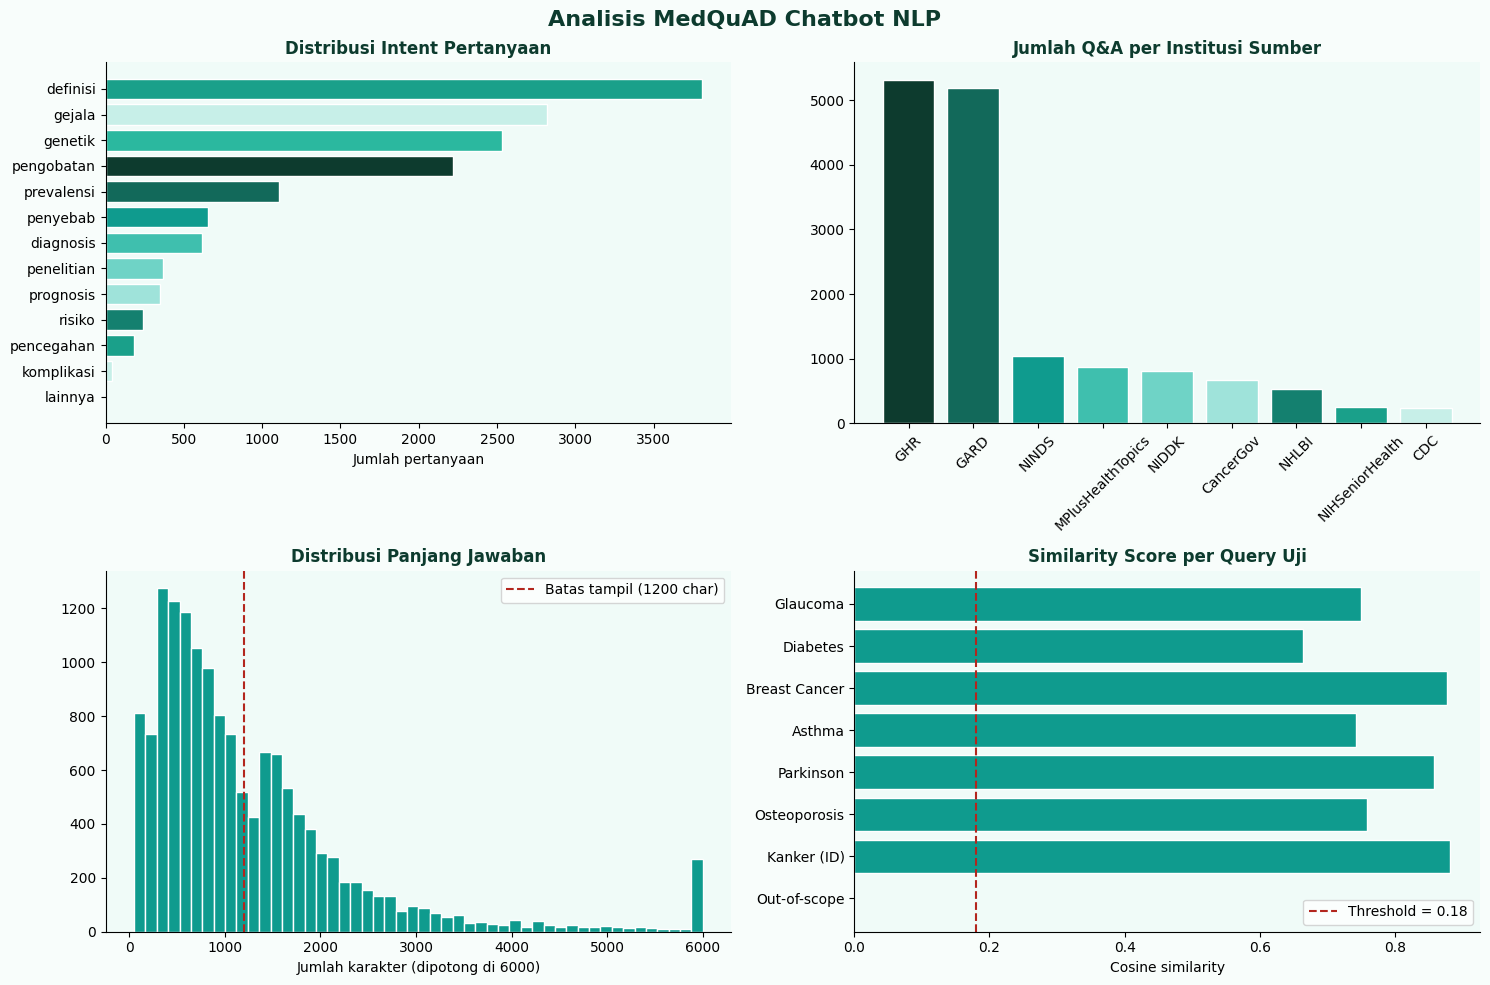


🔑 20 ISTILAH PALING INFORMATIF (rata-rata bobot TF-IDF tertinggi):
    1. syndrome                     0.03293
    2. symptom                      0.02617
    3. treatment                    0.02443
    4. definisi                     0.02162
    5. genetic                      0.02022
    6. disease                      0.01701
    7. gejala symptom               0.01580
    8. gejala                       0.01580
    9. genetik genetic              0.01565
   10. genetik                      0.01565
   11. pengobatan treatment         0.01444
   12. pengobatan                   0.01444
   13. type                         0.01237
   14. deficiency                   0.01186
   15. inherited                    0.01085
   16. inherited genetik            0.01076
   17. cause                        0.01015
   18. related                      0.00966
   19. diagnosis                    0.00954
   20. people                       0.00865


In [ ]:
# ============================================================
# ANALISIS DATASET & MODEL
# ============================================================
import matplotlib.pyplot as plt

PALETTE = ['#0d3b2e', '#12695a', '#0f9b8e', '#3fbfae', '#6fd3c6',
           '#9fe3da', '#14806f', '#1aa08a', '#c7efe8', '#2bb89f']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor('#f8fdfb')
plt.suptitle('Analisis MedQuAD Chatbot NLP', fontsize=16, fontweight='bold',
             color='#0d3b2e', y=0.98)

# ── Plot 1: Distribusi Intent ──
ic = df['intent'].value_counts()
axes[0, 0].barh(ic.index[::-1], ic.values[::-1],
                color=PALETTE[:len(ic)][::-1], edgecolor='white')
axes[0, 0].set_title('Distribusi Intent Pertanyaan', fontweight='bold', color='#0d3b2e')
axes[0, 0].set_xlabel('Jumlah pertanyaan')
axes[0, 0].set_facecolor('#f0fbf8')
axes[0, 0].spines[['top', 'right']].set_visible(False)

# ── Plot 2: Sumber institusi ──
sc = df['source'].value_counts()
axes[0, 1].bar(sc.index, sc.values, color=PALETTE[:len(sc)], edgecolor='white')
axes[0, 1].set_title('Jumlah Q&A per Institusi Sumber', fontweight='bold', color='#0d3b2e')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_facecolor('#f0fbf8')
axes[0, 1].spines[['top', 'right']].set_visible(False)

# ── Plot 3: Distribusi panjang jawaban ──
axes[1, 0].hist(df['answer_len'].clip(upper=6000), bins=50,
                color='#0f9b8e', edgecolor='white')
axes[1, 0].axvline(bot.max_answer_chars, color='#b3261e', linestyle='--',
                   label=f'Batas tampil ({bot.max_answer_chars} char)')
axes[1, 0].set_title('Distribusi Panjang Jawaban', fontweight='bold', color='#0d3b2e')
axes[1, 0].set_xlabel('Jumlah karakter (dipotong di 6000)')
axes[1, 0].legend()
axes[1, 0].set_facecolor('#f0fbf8')
axes[1, 0].spines[['top', 'right']].set_visible(False)

# ── Plot 4: Similarity score untuk berbagai query uji ──
test_cases = [
    ("what are the symptoms of glaucoma", "Glaucoma"),
    ("how to prevent diabetes",           "Diabetes"),
    ("treatments for breast cancer",      "Breast Cancer"),
    ("what causes asthma",                "Asthma"),
    ("is parkinson disease inherited",    "Parkinson"),
    ("how many people have osteoporosis", "Osteoporosis"),
    ("gejala kanker payudara",            "Kanker (ID)"),
    ("xyzabc qwerty nonsense",            "Out-of-scope"),
]
labels, scores = [], []
for query, label in test_cases:
    _, score = bot._find_best_match(query)
    labels.append(label)
    scores.append(score)

colors = ['#0f9b8e' if s >= bot.threshold else '#b3261e' for s in scores]
axes[1, 1].barh(labels[::-1], scores[::-1], color=colors[::-1], edgecolor='white')
axes[1, 1].axvline(bot.threshold, color='#b3261e', linestyle='--',
                   label=f'Threshold = {bot.threshold}')
axes[1, 1].set_title('Similarity Score per Query Uji', fontweight='bold', color='#0d3b2e')
axes[1, 1].set_xlabel('Cosine similarity')
axes[1, 1].legend()
axes[1, 1].set_facecolor('#f0fbf8')
axes[1, 1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# ── Top TF-IDF features ──
feature_names = np.array(bot.vectorizer.get_feature_names_out())
mean_tfidf = np.asarray(bot.tfidf_matrix.mean(axis=0)).ravel()
top20 = mean_tfidf.argsort()[-20:][::-1]
print("\n🔑 20 ISTILAH PALING INFORMATIF (rata-rata bobot TF-IDF tertinggi):")
for rank, i in enumerate(top20, 1):
    print(f"   {rank:2d}. {feature_names[i]:<28} {mean_tfidf[i]:.5f}")

In [ ]:
# ============================================================
# (A) EVALUASI OTOMATIS — 400 QUERY PARAFRASE
# ============================================================
INTENT_PHRASE = {
    'gejala':     'symptoms of',       'penyebab':   'what causes',
    'pengobatan': 'treatments for',    'pencegahan': 'how to prevent',
    'diagnosis':  'how to diagnose',   'prevalensi': 'how many people have',
    'genetik':    'is inherited',      'penelitian': 'research on',
    'prognosis':  'outlook for',       'komplikasi': 'complications of',
    'risiko':     'who is at risk for','definisi':   'what is',
    'lainnya':    'information about',
}

N_TEST = 400
sample = df.sample(N_TEST, random_state=42)

top1_hit, top3_hit, focus_hit = 0, 0, 0
t0 = time.time()

for _, row in sample.iterrows():
    # Bangun query parafrase (BUKAN kalimat asli di dataset)
    query = f"{INTENT_PHRASE[row['intent']]} {row['focus_area']}"

    results = bot._rerank(query, bot._search_tfidf(query))

    def match(i):
        r = bot.df.iloc[i]
        return (r['focus_area'].lower() == row['focus_area'].lower()
                and r['intent'] == row['intent'])

    top1_hit  += match(results[0][0])
    top3_hit  += any(match(i) for i, _ in results[:3])
    focus_hit += (bot.df.iloc[results[0][0]]['focus_area'].lower()
                  == row['focus_area'].lower())

elapsed = time.time() - t0

print("=" * 70)
print("LAPORAN EVALUASI OTOMATIS — MedQuAD Bot")
print("=" * 70)
print(f"Jumlah query uji        : {N_TEST}")
print(f"Metode retrieval        : {'SBERT' if USE_SBERT else 'TF-IDF'} + keyword/intent re-ranking")
print("-" * 70)
print(f"Top-1 Accuracy (focus+intent) : {top1_hit/N_TEST:>7.2%}  ({top1_hit}/{N_TEST})")
print(f"Top-3 Accuracy (focus+intent) : {top3_hit/N_TEST:>7.2%}  ({top3_hit}/{N_TEST})")
print(f"Topic Accuracy (focus saja)   : {focus_hit/N_TEST:>7.2%}  ({focus_hit}/{N_TEST})")
print("-" * 70)
print(f"Rata-rata waktu respons       : {elapsed/N_TEST*1000:>7.1f} ms per query")
print("=" * 70)

LAPORAN EVALUASI OTOMATIS — MedQuAD Bot
Jumlah query uji        : 400
Metode retrieval        : TF-IDF + keyword/intent re-ranking
----------------------------------------------------------------------
Top-1 Accuracy (focus+intent) :  93.25%  (373/400)
Top-3 Accuracy (focus+intent) :  97.00%  (388/400)
Topic Accuracy (focus saja)   :  94.50%  (378/400)
----------------------------------------------------------------------
Rata-rata waktu respons       :    17.0 ms per query


In [ ]:
# ============================================================
# (B) EVALUASI SKENARIO MANUAL
# ============================================================
test_scenarios = [
    # (input, kata kunci yang diharapkan muncul, deskripsi)
    ("What are the symptoms of Glaucoma ?", "glaucoma",     "Pertanyaan persis seperti dataset"),
    ("symptoms of glaucoma",                "glaucoma",     "Parafrase — tanpa kata tanya"),
    ("my eye pressure is high what disease", "glaucoma",     "Deskriptif — tanpa nama penyakit"),
    ("how do I prevent diabetes",            "diabetes",     "Parafrase intent pencegahan"),
    ("treatments for breast cancer",         "breast cancer","Intent pengobatan"),
    ("what causes asthma",                   "asthma",       "Intent penyebab"),
    ("is parkinson disease inherited",       "parkinson",    "Intent genetik"),
    ("gejala kanker payudara",               "breast cancer","Query Bahasa Indonesia"),
    ("cara mencegah stroke",                 "stroke",       "Query Bahasa Indonesia"),
    ("halo selamat pagi",                    "medquad",      "Rule-based: salam"),
    ("topik apa saja yang tersedia",         "topik",        "Rule-based: kapabilitas"),
    ("terima kasih banyak",                  "sama-sama",    "Rule-based: terima kasih"),
    ("ayah saya pingsan tidak sadarkan diri","darurat",      "Rule-based: DARURAT"),
    ("nyeri dada berat menjalar ke lengan",  "darurat",      "Rule-based: DARURAT"),
    ("zxcvbn qwerty asdfgh 12345",           "tidak menemukan", "Out-of-scope harus ditolak"),
]

print("=" * 70)
print("LAPORAN EVALUASI SKENARIO — MedQuAD Bot")
print("=" * 70)

correct = 0
for user_input, expected, description in test_scenarios:
    bot.last_focus = None                       # isolasi tiap skenario
    response = bot.get_response(user_input).lower()
    ok = expected.lower() in response
    correct += ok
    print(f"{'✅' if ok else '❌'} {description}")
    print(f"   Input    : {user_input}")
    print(f"   Harapan  : mengandung '{expected}'")
    print(f"   Cuplikan : {' '.join(response.split())[:110]}…\n")

print("-" * 70)
print(f"Skor skenario : {correct}/{len(test_scenarios)} = {correct/len(test_scenarios):.2%}")
print("=" * 70)

LAPORAN EVALUASI SKENARIO — MedQuAD Bot
✅ Pertanyaan persis seperti dataset
   Input    : What are the symptoms of Glaucoma ?
   Harapan  : mengandung 'glaucoma'
   Cuplikan : 🩺 **glaucoma** — *gejala* symptoms of glaucoma glaucoma can develop in one or both eyes. the most common type …

✅ Parafrase — tanpa kata tanya
   Input    : symptoms of glaucoma
   Harapan  : mengandung 'glaucoma'
   Cuplikan : 🩺 **glaucoma** — *gejala* symptoms of glaucoma glaucoma can develop in one or both eyes. the most common type …

❌ Deskriptif — tanpa nama penyakit
   Input    : my eye pressure is high what disease
   Harapan  : mengandung 'glaucoma'
   Cuplikan : 🩺 **high blood pressure** — *definisi* high blood pressure is a common disease in which blood flows through bl…

✅ Parafrase intent pencegahan
   Input    : how do I prevent diabetes
   Harapan  : mengandung 'diabetes'
   Cuplikan : 🩺 **diabetes** — *definisi* too much glucose in the blood diabetes means your blood glucose (often called bloo…



In [ ]:
# ============================================================
# (C) UJI MEMORI PERCAKAPAN (CONTEXT-AWARE FOLLOW-UP)
# ============================================================
bot.conversation_history, bot.last_focus = [], None

dialog = [
    "what is glaucoma",      # menetapkan topik
    "symptoms",              # follow-up singkat — harus tetap tentang Glaucoma
    "treatments",            # follow-up singkat — harus tetap tentang Glaucoma
]

print("=" * 70)
print("UJI MEMORI PERCAKAPAN")
print("=" * 70)
for q in dialog:
    resp = bot.get_response(q)
    topic = resp.split('**')[1] if '**' in resp else '-'
    print(f"👤 {q:<18} → 🤖 topik terdeteksi: {topic}")
print("\n💡 Tanpa memori percakapan, query 'symptoms' saja akan ambigu "
      "karena ada ribuan penyakit yang punya gejala.")

UJI MEMORI PERCAKAPAN
👤 what is glaucoma   → 🤖 topik terdeteksi: Glaucoma
👤 symptoms           → 🤖 topik terdeteksi: Glaucoma
👤 treatments         → 🤖 topik terdeteksi: Glaucoma

💡 Tanpa memori percakapan, query 'symptoms' saja akan ambigu karena ada ribuan penyakit yang punya gejala.
